# 情绪因子测试

因子定义：`情绪因子 = ts_rank(涨停家数, 252) - ts_rank(跌停家数, 252) + ts_rank(昨日涨停今日溢价, 252)`

- 涨停家数：每日全市场涨停家数，取252日滚动排名
- 跌停家数：每日全市场跌停家数，取252日滚动排名
- 昨日涨停今日溢价：昨日涨停股票今日的收盘收益率（等权平均），取252日滚动排名
- ts_rank：过去252天的百分位排名（0-1）

In [1]:
# 数据准备
%reload_ext autoreload
%autoreload 2
import sys
sys.path.append(r"C:\Users\20561\Desktop\策略")
from fun import *
from mapping import *
from stock_api import stock_api
import polars as pl
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

start_date = dt.date(2023, 1, 1)
end_date = dt.date(2026, 1, 1)
print(f"测试时间范围: {start_date} ~ {end_date}")

# 读取日线数据
stock_data = read_day_data(start_date=start_date, end_date=end_date, file_path='ts_stock_all_data')
stock_data = stock_data.drop_nulls(subset=['open', 'close', 'pre_close', 'limit_up', 'limit_down'])
print(f"数据加载完成: {stock_data.shape}")
print(f"股票数量: {stock_data['code'].n_unique()}")
print(f"交易日数量: {stock_data['trading_date'].n_unique()}")

# 标记涨停状态
stock_data = mark_limit_status(stock_data)
print("涨停状态标记完成")

测试时间范围: 2023-01-01 ~ 2026-01-01
数据加载完成: (3691313, 33)
股票数量: 5309
交易日数量: 727
涨停状态标记完成


情绪因子计算完成:
              limit_up_rank  limit_down_rank  limit_up_premium_rank  \
trading_date                                                          
2025-12-18       0.44841270       0.32142857             0.78571429   
2025-12-19       0.68650794       0.23412698             0.81349206   
2025-12-22       0.91269841       0.36904762             0.57539683   
2025-12-23       0.41666667       0.65079365             0.30555556   
2025-12-24       0.71825397       0.23809524             0.63888889   
2025-12-25       0.82142857       0.04365079             0.86507937   
2025-12-26       0.77777778       0.08333333             0.61507937   
2025-12-29       0.75793651       0.78174603             0.18253968   
2025-12-30       0.38888889       0.71428571             0.24603175   
2025-12-31       0.30158730       0.60317460             0.31746032   

              sentiment_factor  
trading_date                    
2025-12-18          0.91269841  
2025-12-19          1.26587302  
2025-

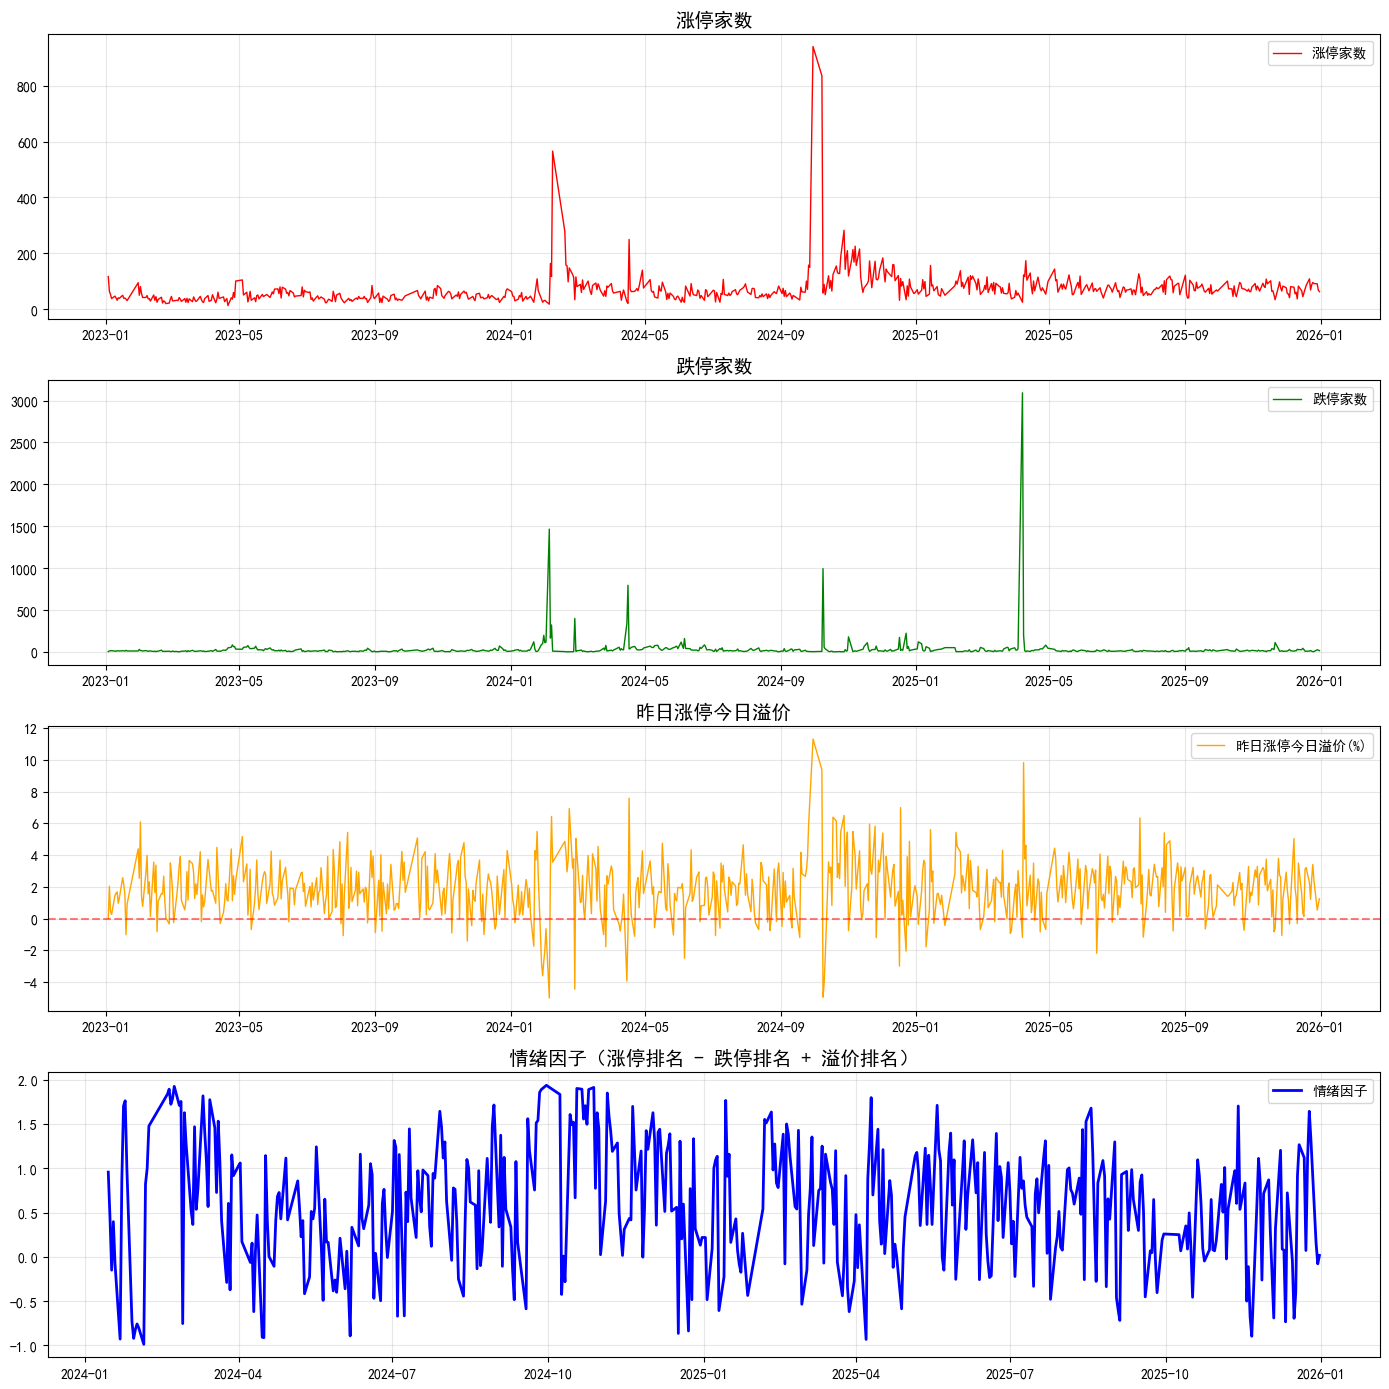

In [2]:
# 因子计算

# 1. 计算每日涨跌停家数
daily_stats = stock_data.group_by('trading_date').agg([
    pl.col('is_limit_up').sum().cast(pl.Int64).alias('limit_up_count'),
    ((pl.col('close') <= pl.col('limit_down') * 1.001)).sum().cast(pl.Int64).alias('limit_down_count')
]).sort('trading_date')

# 2. 计算昨日涨停股票今日的溢价
stock_data = stock_data.sort(['code', 'trading_date'])
stock_data = stock_data.with_columns([
    pl.col('is_limit_up').shift(1).over('code').alias('yesterday_limit_up')
])
stock_data = stock_data.with_columns([
    ((pl.col('close') - pl.col('pre_close')) / pl.col('pre_close') * 100).alias('today_return')
])
yesterday_limit_stocks = stock_data.filter(pl.col('yesterday_limit_up') == True)
daily_premium = yesterday_limit_stocks.group_by('trading_date').agg([
    pl.col('today_return').mean().alias('limit_up_premium'),
    pl.col('code').count().alias('pre_limit_up_stock_count')
]).sort('trading_date')

# 3. 合并两个指标
market_sentiment = daily_stats.join(daily_premium, on='trading_date', how='left').sort('trading_date')
market_sentiment = market_sentiment.with_columns([
    pl.col('limit_up_premium').fill_null(0)
])

# 4. 计算252日滚动百分位排名（ts_rank）
def rolling_percent_rank(series, window=252):
    """计算滚动百分位排名（0-1）"""
    ranks = []
    for i in range(len(series)):
        if i < window - 1:
            ranks.append(np.nan)
        else:
            window_data = series.iloc[i-window+1:i+1]
            current_value = series.iloc[i]
            rank = (window_data <= current_value).sum() / len(window_data)
            ranks.append(rank)
    return pd.Series(ranks, index=series.index)

market_sentiment_pd = market_sentiment.to_pandas().set_index('trading_date')

# 新因子：分别计算涨停家数排名和跌停家数排名
market_sentiment_pd['limit_up_rank'] = rolling_percent_rank(market_sentiment_pd['limit_up_count'], 252)
market_sentiment_pd['limit_down_rank'] = rolling_percent_rank(market_sentiment_pd['limit_down_count'], 252)
market_sentiment_pd['limit_up_premium_rank'] = rolling_percent_rank(market_sentiment_pd['limit_up_premium'], 252)

# 新因子计算公式
market_sentiment_pd['sentiment_factor'] = (
    market_sentiment_pd['limit_up_rank'] - 
    market_sentiment_pd['limit_down_rank'] + 
    market_sentiment_pd['limit_up_premium_rank']
)

print("情绪因子计算完成:")
print(market_sentiment_pd[['limit_up_rank', 'limit_down_rank', 'limit_up_premium_rank', 'sentiment_factor']].tail(10))

# 画出情绪因子时序图
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# 涨停家数
axes[0].plot(market_sentiment_pd.index, market_sentiment_pd['limit_up_count'], label='涨停家数', color='red', linewidth=1)
axes[0].set_title('涨停家数', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 跌停家数
axes[1].plot(market_sentiment_pd.index, market_sentiment_pd['limit_down_count'], label='跌停家数', color='green', linewidth=1)
axes[1].set_title('跌停家数', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# 昨日涨停溢价
axes[2].plot(market_sentiment_pd.index, market_sentiment_pd['limit_up_premium'], label='昨日涨停今日溢价(%)', color='orange', linewidth=1)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('昨日涨停今日溢价', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

# 情绪因子
axes[3].plot(market_sentiment_pd.index, market_sentiment_pd['sentiment_factor'], label='情绪因子', color='blue', linewidth=2)
axes[3].set_title('情绪因子（涨停排名 - 跌停排名 + 溢价排名）', fontsize=14)
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# 指数数据准备

# 使用gm_get_index_day_data获取中证1000指数
from stock_api import stock_api
api = stock_api()

print("正在获取中证1000指数数据...")
index_data = api.gm_get_index_day_data(
    index_code='SHSE.000852',
    start_date=start_date.strftime('%Y-%m-%d'),
    end_date=end_date.strftime('%Y-%m-%d')
)
print(f"中证1000指数数据获取完成: {index_data.shape}")

# 确保trading_date格式正确并设为索引
index_data['trading_date'] = pd.to_datetime(index_data['trading_date']).dt.date
index_data = index_data.set_index('trading_date').sort_index()

# 计算每日收益率
index_data['daily_return'] = (index_data['close'] / index_data['pre_close'] - 1) * 100
index_data['nav'] = (1 + index_data['daily_return'] / 100).cumprod()

# 合并情绪因子和指数数据
analysis_data = pd.merge(
    market_sentiment_pd[['sentiment_factor', 'limit_up_rank', 'limit_down_rank', 'limit_up_premium_rank']],
    index_data[['daily_return', 'nav']],
    left_index=True, right_index=True, how='inner'
)

# 计算未来N日收益率
for period in [1, 2, 3, 5, 10, 20]:
    analysis_data[f'future_return_{period}d'] = (
        analysis_data['nav'].shift(-period) / analysis_data['nav'] - 1
    ) * 100

print(f"分析数据 shape: {analysis_data.shape}")

正在获取中证1000指数数据...
中证1000指数数据获取完成: (727, 13)
分析数据 shape: (727, 12)


In [7]:
# 相关性分析

# 计算情绪因子与未来收益的相关系数
corr_results = []
for period in [1, 2, 3, 5, 10, 20]:
    corr = analysis_data['sentiment_factor'].corr(analysis_data[f'future_return_{period}d'])
    corr_results.append({
        '持仓周期': f'{period}天',
        '相关系数': corr
    })

corr_df = pd.DataFrame(corr_results)
print("情绪因子与未来收益的相关性:")
print(corr_df)

print("\n涨停家数排名与未来收益的相关性:")
for period in [1, 2, 3, 5, 10, 20]:
    corr = analysis_data['limit_up_rank'].corr(analysis_data[f'future_return_{period}d'])
    print(f"{period}天: {corr:.4f}")

print("\n跌停家数排名与未来收益的相关性:")
for period in [1, 2, 3, 5, 10, 20]:
    corr = analysis_data['limit_down_rank'].corr(analysis_data[f'future_return_{period}d'])
    print(f"{period}天: {corr:.4f}")

print("\n溢价排名与未来收益的相关性:")
for period in [1, 2, 3, 5, 10, 20]:
    corr = analysis_data['limit_up_premium_rank'].corr(analysis_data[f'future_return_{period}d'])
    print(f"{period}天: {corr:.4f}")



情绪因子与未来收益的相关性:
  持仓周期        相关系数
0   1天  0.05062869
1   2天  0.07857096
2   3天  0.06509677
3   5天  0.04499139
4  10天  0.02760030
5  20天  0.02833494

涨停家数排名与未来收益的相关性:
1天: 0.0322
2天: 0.0515
3天: 0.0365
5天: 0.0207
10天: -0.0462
20天: -0.0690

跌停家数排名与未来收益的相关性:
1天: -0.0711
2天: -0.0740
3天: -0.0685
5天: -0.0569
10天: -0.0840
20天: -0.1221

溢价排名与未来收益的相关性:
1天: 0.0229
2天: 0.0690
3天: 0.0562
5天: 0.0339
10天: 0.0291
20天: 0.0146


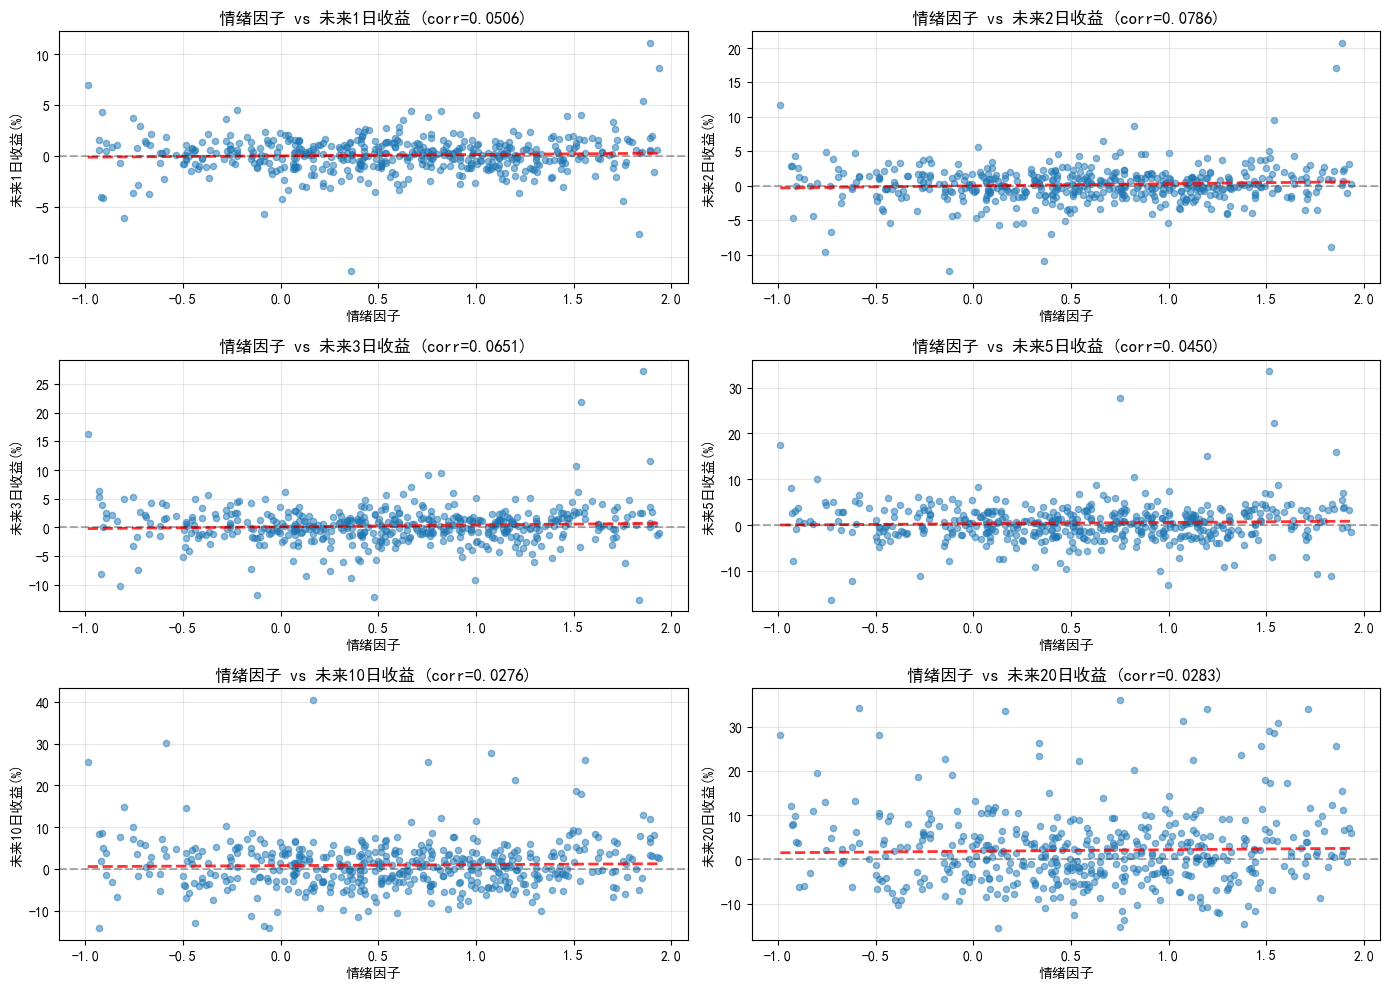

In [8]:
# 散点图
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
periods = [1, 2, 3, 5, 10, 20]

for i, period in enumerate(periods):
    ax = axes[i//2, i%2]
    valid_data = analysis_data[['sentiment_factor', f'future_return_{period}d']].dropna()
    ax.scatter(valid_data['sentiment_factor'], valid_data[f'future_return_{period}d'], alpha=0.5, s=20)
    
    if len(valid_data) > 2:
        try:
            z = np.polyfit(valid_data['sentiment_factor'], valid_data[f'future_return_{period}d'], 1)
            p = np.poly1d(z)
            x_range = np.linspace(valid_data['sentiment_factor'].min(), valid_data['sentiment_factor'].max(), 100)
            ax.plot(x_range, p(x_range), "r--", alpha=0.8, linewidth=2)
        except Exception as e:
            pass
    
    corr = analysis_data['sentiment_factor'].corr(analysis_data[f'future_return_{period}d'])
    ax.set_title(f'情绪因子 vs 未来{period}日收益 (corr={corr:.4f})', fontsize=12)
    ax.set_xlabel('情绪因子')
    ax.set_ylabel(f'未来{period}日收益(%)')
    ax.grid(alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

情绪因子分组未来3日收益统计:
              平均收益(%)   收益标准差  样本数
factor_group                      
G1             0.4413  3.6544   95
G2            -0.5005  2.5692   93
G3             0.2453  2.8376   95
G4             0.1238  2.4369   95
G5             0.9792  4.7430   95


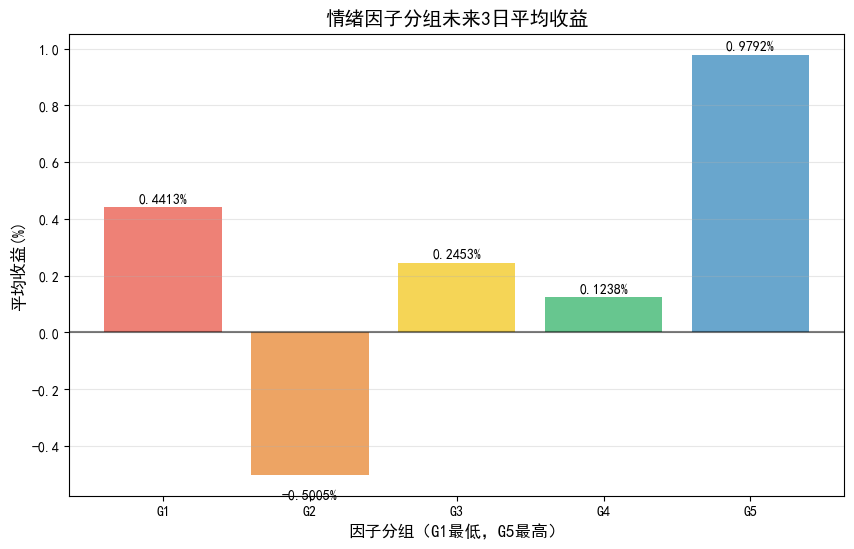


所有分组策略回测完成
所有分组策略表现汇总
           累计收益     年化收益   夏普比率     最大回撤      胜率     持仓占比
分组                                                       
G1      -48.34%  -29.51%  -1.68  -53.05%  20.80%   44.75%
G2      -42.14%  -25.15%  -1.84  -48.17%  21.64%   46.43%
G3       17.80%    9.06%   0.45  -11.50%  26.89%   50.00%
G4       76.47%   35.08%   1.90   -9.49%  27.52%   47.06%
G5      175.50%   71.00%   2.67   -8.83%  25.63%   39.29%
买入持有基准   36.25%   17.79%   0.61  -22.78%  54.62%  100.00%


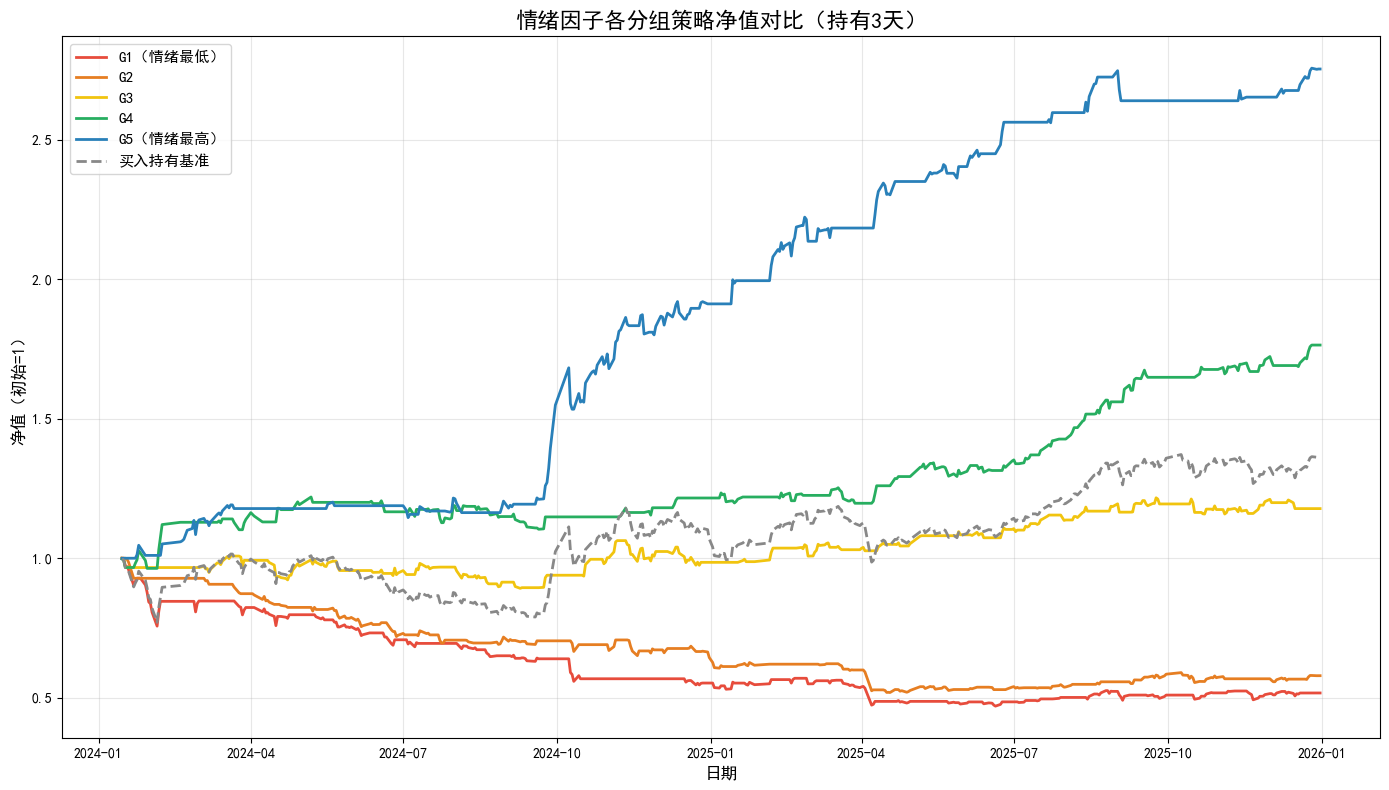

In [5]:
# 分组测试与分组策略回测

hold_period = 3

# 将情绪因子分为5组
analysis_data_clean = analysis_data.dropna(subset=['sentiment_factor']).copy()
analysis_data_clean['factor_group'] = pd.qcut(analysis_data_clean['sentiment_factor'], 
                                               q=5, labels=['G1', 'G2', 'G3', 'G4', 'G5'])

# 看每组的未来收益
group_returns = analysis_data_clean.groupby('factor_group')[f'future_return_{hold_period}d'].agg([
    'mean', 'std', 'count'
])
group_returns.columns = ['平均收益(%)', '收益标准差', '样本数']

print(f"情绪因子分组未来{hold_period}日收益统计:")
print(group_returns.round(4))

# 画柱状图
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2980b9']
bars = plt.bar(group_returns.index, group_returns['平均收益(%)'], color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height>0 else -0.05),
             f'{height:.4f}%', ha='center', va='bottom' if height>0 else 'top')

plt.title(f'情绪因子分组未来{hold_period}日平均收益', fontsize=14)
plt.xlabel('因子分组（G1最低，G5最高）', fontsize=12)
plt.ylabel('平均收益(%)', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.show()

# ========== 每个分组作为独立策略回测 ==========

def backtest_group_strategy(data, group_col, target_group, hold_period=5):
    """单个分组策略回测"""
    data = data.copy().dropna(subset=[group_col])
    data['signal'] = (data[group_col] == target_group).astype(int)
    
    signal_arr = data['signal'].to_numpy()
    position = np.zeros(len(data), dtype=np.int8)
    remaining_days = 0

    for i, s in enumerate(signal_arr):
        if s == 1:
            remaining_days = hold_period
        if remaining_days > 0:
            position[i] = 1
            remaining_days -= 1

    data['position'] = position
    data['strategy_return'] = data['position'] * data['daily_return'] / 100
    data['strategy_nav'] = (1 + data['strategy_return']).cumprod()

    return data

def calculate_group_performance_metrics(data, group_name):
    """计算分组策略表现指标"""
    returns = data['strategy_return'].dropna()
    nav = data['strategy_nav'].dropna()
    
    if len(returns) == 0:
        return None
    
    total_return = nav.iloc[-1] - 1
    years = len(returns) / 252
    annual_return = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    
    daily_rf = 0.03 / 252
    excess_return = returns - daily_rf
    sharpe = np.sqrt(252) * excess_return.mean() / returns.std() if returns.std() > 0 else 0
    
    peak = nav.expanding().max()
    drawdown = (nav - peak) / peak
    max_drawdown = drawdown.min()
    
    win_rate = (returns > 0).mean()
    position_days = (data['position'] == 1).sum()
    position_ratio = position_days / len(data)
    
    return {
        '分组': group_name,
        '累计收益': total_return * 100,
        '年化收益': annual_return * 100,
        '夏普比率': sharpe,
        '最大回撤': max_drawdown * 100,
        '胜率': win_rate * 100,
        '持仓占比': position_ratio * 100
    }

# 对每个分组进行回测
groups = ['G1', 'G2', 'G3', 'G4', 'G5']
group_results = {}

for group in groups:
    group_strategy = backtest_group_strategy(
        analysis_data_clean, 'factor_group', target_group=group, hold_period=hold_period
    )
    group_results[group] = group_strategy

print("\n所有分组策略回测完成")

# 计算所有分组的表现
all_metrics = []
for group in groups:
    metrics = calculate_group_performance_metrics(group_results[group], group)
    all_metrics.append(metrics)

# 添加基准
benchmark_data = analysis_data_clean.copy()
benchmark_data['position'] = 1
benchmark_data['strategy_return'] = benchmark_data['daily_return'] / 100
benchmark_data['strategy_nav'] = (1 + benchmark_data['strategy_return']).cumprod()
benchmark_metrics = calculate_group_performance_metrics(benchmark_data, '买入持有基准')
all_metrics.append(benchmark_metrics)

# 显示格式化后的表格
metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df.set_index('分组')

print("="*90)
print("所有分组策略表现汇总")
print("="*90)
display_df = metrics_df.copy()
for col in ['累计收益', '年化收益', '最大回撤', '胜率', '持仓占比']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.2f}%')
display_df['夏普比率'] = display_df['夏普比率'].apply(lambda x: f'{x:.2f}')
print(display_df)

# 画出所有分组策略的净值曲线对比
plt.figure(figsize=(14, 8))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2980b9', '#888888']
labels = ['G1（情绪最低）', 'G2', 'G3', 'G4', 'G5（情绪最高）', '买入持有基准']

for i, group in enumerate(groups + ['基准']):
    if group == '基准':
        nav = benchmark_data['strategy_nav']
        linestyle = '--'
        linewidth = 2
    else:
        nav = group_results[group]['strategy_nav']
        linestyle = '-'
        linewidth = 2
    
    plt.plot(nav.index, nav, label=labels[i], color=colors[i], 
             linestyle=linestyle, linewidth=linewidth)

plt.title(f'情绪因子各分组策略净值对比（持有{hold_period}天）', fontsize=16)
plt.xlabel('日期', fontsize=12)
plt.ylabel('净值（初始=1）', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

策略回测完成

策略1：情绪因子高时做多
累计收益: 209.45%
年化收益: 81.85%
夏普比率: 3.13
最大回撤: -4.82%
胜率: 24.79%
持仓占比: 37.18%

策略2：情绪因子低时做多（逆向策略）
累计收益: -62.86%
年化收益: -40.81%
夏普比率: -2.78
最大回撤: -63.96%
胜率: 15.13%
持仓占比: 36.97%

基准：买入持有中证1000
累计收益: 36.25%
年化收益: 17.79%
夏普比率: 0.61
最大回撤: -22.78%
胜率: 54.62%
持仓占比: 100.00%


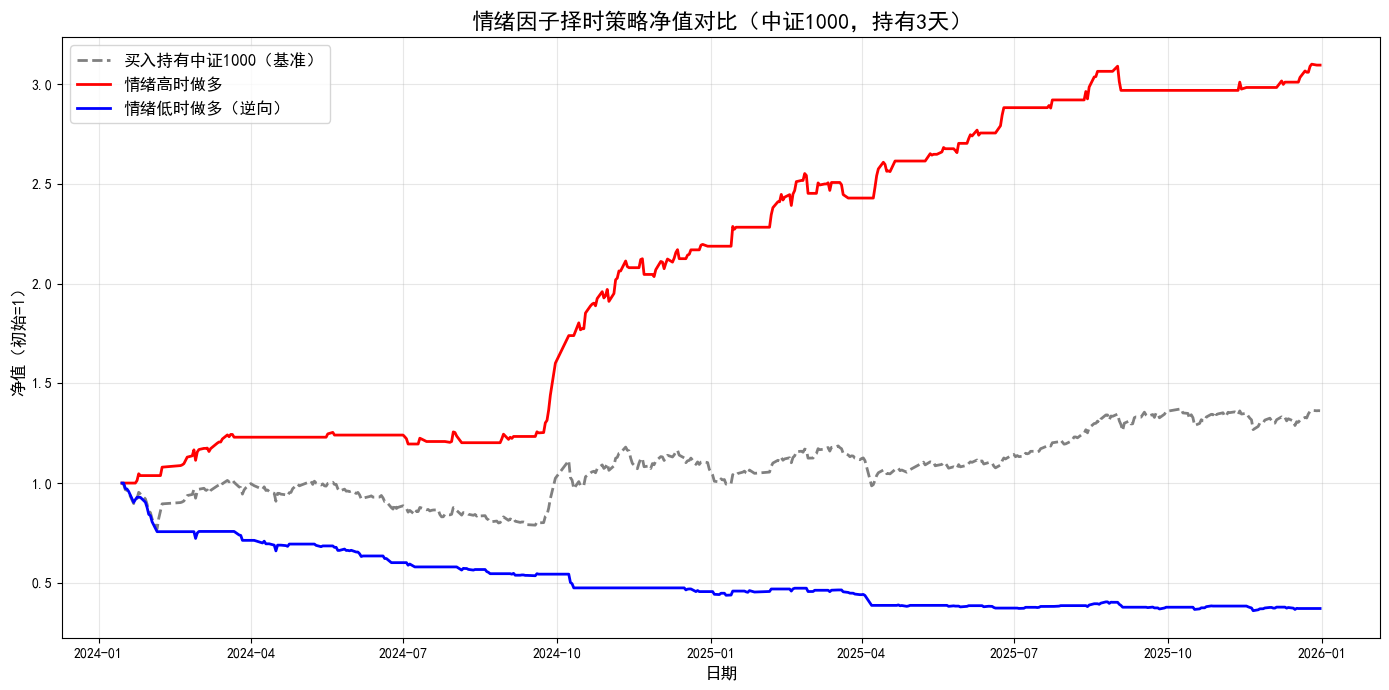

In [6]:
# 择时策略回测

def backtest_timing_strategy(data, factor_col, signal_type='high', hold_period=5, threshold=0.8):
    """择时策略回测"""
    data = data.copy().dropna(subset=[factor_col])
    
    if signal_type == 'high':
        threshold_value = data[factor_col].quantile(threshold)
        data['signal'] = (data[factor_col] >= threshold_value).astype(int)
    else:  # low
        threshold_value = data[factor_col].quantile(1 - threshold)
        data['signal'] = (data[factor_col] <= threshold_value).astype(int)
    
    data['position'] = 0
    in_position = False
    hold_days = 0
    
    for i in range(len(data)):
        if not in_position and data['signal'].iloc[i] == 1:
            in_position = True
            hold_days = 0
        
        if in_position:
            data['position'].iloc[i] = 1
            hold_days += 1
            if hold_days >= hold_period:
                in_position = False
    
    data['strategy_return'] = data['position'] * data['daily_return'] / 100
    data['benchmark_return'] = data['daily_return'] / 100
    data['strategy_nav'] = (1 + data['strategy_return']).cumprod()
    data['benchmark_nav'] = (1 + data['benchmark_return']).cumprod()
    
    return data

def calculate_performance_metrics(data, return_col, nav_col):
    """计算策略表现指标"""
    returns = data[return_col].dropna()
    nav = data[nav_col].dropna()
    
    if len(returns) == 0:
        return None
    
    total_return = nav.iloc[-1] - 1
    years = len(returns) / 252
    annual_return = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    
    daily_rf = 0.03 / 252
    excess_return = returns - daily_rf
    sharpe = np.sqrt(252) * excess_return.mean() / returns.std() if returns.std() > 0 else 0
    
    peak = nav.expanding().max()
    drawdown = (nav - peak) / peak
    max_drawdown = drawdown.min()
    
    win_rate = (returns > 0).mean()
    position_days = (data['position'] == 1).sum()
    position_ratio = position_days / len(data)
    
    return {
        '累计收益': f'{total_return*100:.2f}%',
        '年化收益': f'{annual_return*100:.2f}%',
        '夏普比率': f'{sharpe:.2f}',
        '最大回撤': f'{max_drawdown*100:.2f}%',
        '胜率': f'{win_rate*100:.2f}%',
        '持仓占比': f'{position_ratio*100:.2f}%'
    }

# 回测两种策略
threshold = 0.8

strategy_high = backtest_timing_strategy(
    analysis_data, 'sentiment_factor', signal_type='high', 
    hold_period=hold_period, threshold=threshold
)

strategy_low = backtest_timing_strategy(
    analysis_data, 'sentiment_factor', signal_type='low', 
    hold_period=hold_period, threshold=threshold
)

print("策略回测完成\n")

print("="*60)
print("策略1：情绪因子高时做多")
print("="*60)
metrics_high = calculate_performance_metrics(strategy_high, 'strategy_return', 'strategy_nav')
for k, v in metrics_high.items():
    print(f"{k}: {v}")

print("\n" + "="*60)
print("策略2：情绪因子低时做多（逆向策略）")
print("="*60)
metrics_low = calculate_performance_metrics(strategy_low, 'strategy_return', 'strategy_nav')
for k, v in metrics_low.items():
    print(f"{k}: {v}")

print("\n" + "="*60)
print("基准：买入持有中证1000")
print("="*60)
benchmark_data = strategy_high.copy()
benchmark_data['position'] = 1
benchmark_data['strategy_return'] = benchmark_data['benchmark_return']
benchmark_data['strategy_nav'] = benchmark_data['benchmark_nav']
metrics_benchmark = calculate_performance_metrics(benchmark_data, 'strategy_return', 'strategy_nav')
for k, v in metrics_benchmark.items():
    print(f"{k}: {v}")

# 画出净值曲线
plt.figure(figsize=(14, 7))

plt.plot(strategy_high.index, strategy_high['benchmark_nav'], 
         label='买入持有中证1000（基准）', color='gray', linewidth=2, linestyle='--')
plt.plot(strategy_high.index, strategy_high['strategy_nav'], 
         label='情绪高时做多', color='red', linewidth=2)
plt.plot(strategy_low.index, strategy_low['strategy_nav'], 
         label='情绪低时做多（逆向）', color='blue', linewidth=2)

plt.title(f'情绪因子择时策略净值对比（中证1000，持有{hold_period}天）', fontsize=16)
plt.xlabel('日期', fontsize=12)
plt.ylabel('净值（初始=1）', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 评价标准与总结

### 1. 相关性系数（Correlation）评价标准

| 相关系数 | 评价 | 说明 |
|---------|------|------|
| \|r\| < 0.05 | 很弱 | 几乎没有预测能力 |
| 0.05 ≤ \|r\| < 0.1 | 较弱 | 有一定预测能力，但不稳定 |
| 0.1 ≤ \|r\| < 0.2 | 中等 | 较好的预测能力 |
| 0.2 ≤ \|r\| < 0.3 | 较强 | 很好的预测能力 |
| \|r\| ≥ 0.3 | 很强 | 非常优秀的预测能力（较少见） |

### 2. 择时策略表现指标评价标准

| 指标 | 较差 | 一般 | 良好 | 优秀 |
|------|------|------|------|------|
| 年化收益 | < 5% | 5-10% | 10-20% | > 20% |
| 夏普比率 | < 0.5 | 0.5-1.0 | 1.0-2.0 | > 2.0 |
| 最大回撤 | > -30% | -20%~-30% | -10%~-20% | < -10% |
| 胜率 | < 50% | 50-55% | 55-60% | > 60% |

### 3. 分组收益单调性评价

- **理想情况**：G1 < G2 < G3 < G4 < G5（单调递增）或 G1 > G2 > G3 > G4 > G5（单调递减）
- **可接受**：G1和G5有明显差异，中间有一定趋势
- **较差**：分组收益混乱，无明显趋势

### 4. 多头空头收益差（G5 - G1）评价标准

| 多空收益差（5日） | 评价 |
|------------------|------|
| < 1% | 较差 |
| 1-2% | 一般 |
| 2-4% | 良好 |
| > 4% | 优秀 |

---

## 总结

这个notebook实现了情绪因子的完整测试流程：

1. **因子计算**（新公式）：
   - 涨停家数的252日百分位排名
   - 跌停家数的252日百分位排名
   - 昨日涨停今日溢价的252日百分位排名
   - 新因子 = 涨停排名 - 跌停排名 + 溢价排名

2. **使用中证1000指数（SHSE.000852）进行测试**

3. **分析内容**：
   - 情绪因子时序图（涨停家数、跌停家数、溢价、情绪因子）
   - 因子与未来收益的相关性（含各分项相关性）
   - 分组测试（G1-G5）
   - 每个分组作为独立策略回测（净值曲线 + 表现指标）
   - 择时策略回测（情绪高/低时做多）
   - 量化因子指标评价标准参考

4. **持仓周期统一为3天**